**Import các thư viện cần thiết**

In [1]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 7.6 MB/s eta 0:00:0000:0100:010m
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395194 sha256=cfc192e3935883f351365b40abaaffcdb848cb95f8b3e5ccca562342f241c879
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


In [28]:
import cv2
import gdown
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix
from google.colab import drive
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from sklearn.ensemble import IsolationForest
from pyclustering.cluster.cure import cure
from pyclustering.utils import draw_clusters
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

**Kết nối Drive lấy tập Dataset xử lý**

In [3]:
print("Đang kéo file chuẩn từ Google Drive về Kaggle...")
file_id = '1KwTKezCswgEkgyUuvsjHGgkCQPYDqG4K' 
url = f'https://drive.google.com/uc?id={file_id}'

# Tải file về đặt tên là LSWMD.pkl
gdown.download(url, 'LSWMD.pkl', quiet=False)
print("Đang load dữ liệu vào RAM...")

file_path = 'LSWMD.pkl'
df = pd.read_pickle(file_path)

# Kiểm tra lại số lượng dòng Null để xác nhận file chuẩn
print(f"Tổng số dòng của bảng: {len(df):,}")
print(f"Số dòng Null trong cột failureType: {df['failureType'].isnull().sum():,}")
print("Đã sẵn sàng chạy tiếp các bước tiếp theo!")

Đang kéo file chuẩn từ Google Drive về Kaggle...


Downloading...
From (original): https://drive.google.com/uc?id=1KwTKezCswgEkgyUuvsjHGgkCQPYDqG4K
From (redirected): https://drive.google.com/uc?id=1KwTKezCswgEkgyUuvsjHGgkCQPYDqG4K&confirm=t&uuid=a6e78452-9a7e-4f8d-9e4d-7c248d17596d
To: /kaggle/working/LSWMD.pkl
100%|██████████| 2.10G/2.10G [00:17<00:00, 120MB/s] 


Đang load dữ liệu vào RAM...
Tổng số dòng của bảng: 811,457
Số dòng Null trong cột failureType: 0
Đã sẵn sàng chạy tiếp các bước tiếp theo!


**Hiển thị dữ liệu**

In [4]:
print("Đang load dữ liệu từ file pickle, quá trình này có thể mất vài phút do file lớn...")
df = pd.read_pickle(file_path)
print("Đã load dữ liệu thành công!\n")

print("="*60)
print("1. KÍCH THƯỚC & DUNG LƯỢNG TẬP DỮ LIỆU")
print("="*60)
print(f"- Tổng số dòng (Mẫu Wafer): {df.shape[0]:,}")
print(f"- Tổng số cột (Đặc trưng): {df.shape[1]}")
# memory_usage='deep' giúp tính toán chính xác số MB RAM mà list/array đang chiếm
df.info(memory_usage='deep')

print("\n" + "="*60)
print("2. THỐNG KÊ DỮ LIỆU THIẾU (MISSING VALUES)")
print("="*60)
# Kiểm tra xem cột nào đang bị trống (NaN) và chiếm tỉ lệ bao nhiêu %
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng Null': missing_data, 'Tỷ lệ Null (%)': missing_percent})
display(missing_df.round(2))

print("\n" + "="*60)
print("3. XEM TRƯỚC DỮ LIỆU (10 DÒNG ĐẦU & 5 DÒNG NGẪU NHIÊN)")
print("="*60)
print("--- 10 dòng đầu tiên (Đầu bảng) ---")
display(df.head(10))

print("\n--- 5 dòng ngẫu nhiên (Lấy random để check độ lộn xộn) ---")
# random_state=42 để mỗi lần chạy đều ra 5 dòng ngẫu nhiên giống nhau
display(df.sample(5, random_state=42))

Đang load dữ liệu từ file pickle, quá trình này có thể mất vài phút do file lớn...
Đã load dữ liệu thành công!

1. KÍCH THƯỚC & DUNG LƯỢNG TẬP DỮ LIỆU
- Tổng số dòng (Mẫu Wafer): 811,457
- Tổng số cột (Đặc trưng): 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 628.9 MB

2. THỐNG KÊ DỮ LIỆU THIẾU (MISSING VALUES)


,Số lượng Null,Tỷ lệ Null (%)
waferMap,0,0.0
dieSize,0,0.0
lotName,0,0.0
waferIndex,0,0.0
trianTestLabel,0,0.0
failureType,0,0.0



3. XEM TRƯỚC DỮ LIỆU (10 DÒNG ĐẦU & 5 DÒNG NGẪU NHIÊN)
--- 10 dòng đầu tiên (Đầu bảng) ---


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]
5,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,6.0,[[Training]],[[none]]
6,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,7.0,[[Training]],[[none]]
7,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,8.0,[[Training]],[[none]]
8,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,9.0,[[Training]],[[none]]
9,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,10.0,[[Training]],[[none]]



--- 5 dòng ngẫu nhiên (Lấy random để check độ lộn xộn) ---


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
552336,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",712.0,lot34696,6.0,[],[]
24803,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",776.0,lot2724,2.0,[],[]
426607,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6052.0,lot25655,12.0,[],[]
722885,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1,...",518.0,lot43945,20.0,[[Test]],[[none]]
192536,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6328.0,lot12178,18.0,[],[]


In [5]:
# 1. Rút phần text ra khỏi mảng 2 chiều một cách an toàn (tránh lỗi float)
df['failureType'] = df['failureType'].apply(
    lambda x: x[0][0] if isinstance(x, (np.ndarray, list)) and len(x) > 0 else np.nan
)
df['trianTestLabel'] = df['trianTestLabel'].apply(
    lambda x: x[0][0] if isinstance(x, (np.ndarray, list)) and len(x) > 0 else np.nan
)

# 2. Xóa các dòng NaN (loại bỏ khoảng 630k ảnh không nhãn lúc này)
df_labeled = df.dropna(subset=['failureType']).copy()

# 3. Đổi tên nhãn 'none' thành 'Normal' cho đúng bản chất
df_labeled['failureType'] = df_labeled['failureType'].replace('none', 'Normal')

# === GỘP CHUNG BƯỚC IN THỐNG KÊ ===
# Tạo một DataFrame thống kê đếm số lượng và tính %
stats_df = df_labeled['failureType'].value_counts().to_frame(name='Số lượng')
stats_df['Tỷ lệ (%)'] = (stats_df['Số lượng'] / len(df_labeled) * 100).round(2)

print("--- THỐNG KÊ PHÂN BỔ 9 NHÃN (Bao gồm Normal + 8 loại lỗi) ---")
display(stats_df)

--- THỐNG KÊ PHÂN BỔ 9 NHÃN (Bao gồm Normal + 8 loại lỗi) ---


,Số lượng,Tỷ lệ (%)
failureType,,
Normal,147431,85.24
Edge-Ring,9680,5.60
Edge-Loc,5189,3.00
Center,4294,2.48
Loc,3593,2.08
Scratch,1193,0.69
Random,866,0.50
Donut,555,0.32
Near-full,149,0.09


In [6]:
# 1. Tách và lấy mẫu Normal bằng với số lượng lỗi
df_normal = df_labeled[df_labeled['failureType'] == 'Normal']
df_defect = df_labeled[df_labeled['failureType'] != 'Normal']

df_normal_sampled = df_normal.sample(n=len(df_defect), random_state=42)
df_subset = pd.concat([df_normal_sampled, df_defect]).reset_index(drop=True)

# 2. Lấy kích thước ma trận siêu tốc bằng lambda và thuộc tính .shape
df_subset['waferMapDim'] = df_subset['waferMap'].apply(lambda x: x.shape)

# === IN KẾT QUẢ TỔNG HỢP ===
print(f" Đã tạo Subset thành công! Tổng số lượng ảnh: {len(df_subset):,}")

print("\n--- PHÂN BỐ 9 NHÃN SAU KHI CÂN BẰNG ---")
display(df_subset['failureType'].value_counts().to_frame(name='Số lượng'))

print("\n--- 5 KÍCH THƯỚC MA TRẬN PHỔ BIẾN NHẤT ---")
display(df_subset['waferMapDim'].value_counts().head().to_frame(name='Số lượng Wafer'))

 Đã tạo Subset thành công! Tổng số lượng ảnh: 51,038

--- PHÂN BỐ 9 NHÃN SAU KHI CÂN BẰNG ---


,Số lượng
failureType,
Normal,25519
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149



--- 5 KÍCH THƯỚC MA TRẬN PHỔ BIẾN NHẤT ---


,Số lượng Wafer
waferMapDim,
"(25, 27)",5639
"(26, 26)",3133
"(30, 34)",2660
"(39, 37)",2641
"(29, 26)",2515


**Bộ subset nhỏ:** (Tỉ lệ 1:1)


In [7]:
# Chọn 64x64 làm chuẩn
TARGET_SIZE = (64, 64)

def resize_wafer_map(wm):
    # Ép kiểu về float32 hoặc uint8 trước khi dùng cv2
    wm_float = wm.astype(np.uint8)
    # Dùng cv2.INTER_NEAREST để bảo toàn tuyệt đối các số nguyên 0, 1, 2
    return cv2.resize(wm_float, dsize=TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

print("Đang đồng bộ kích thước toàn bộ dữ liệu, vui lòng đợi...")
# Tạo cột mới chứa ma trận đã resize
df_subset['waferMap_resized'] = df_subset['waferMap'].apply(resize_wafer_map)

# Kiểm tra thử kích thước của mẫu đầu tiên sau khi xử lý
print("\nKích thước ma trận mẫu 1 sau resize:", df_subset['waferMap_resized'].iloc[0].shape)
print("Các giá trị duy nhất trong ma trận (chỉ được phép có 0, 1, 2):", np.unique(df_subset['waferMap_resized'].iloc[0]))

# Lưu toàn bộ dataframe sạch sẽ này thành một file pickle mới nhẹ gọn hơn
export_path = 'WM811K_subset_clean.pkl'
df_subset.to_pickle(export_path)
print(f"\nĐã xuất file thành phẩm tại thư mục hiện tại của Kaggle: {export_path}")

Đang đồng bộ kích thước toàn bộ dữ liệu, vui lòng đợi...

Kích thước ma trận mẫu 1 sau resize: (64, 64)
Các giá trị duy nhất trong ma trận (chỉ được phép có 0, 1, 2): [0 1 2]

Đã xuất file thành phẩm tại thư mục hiện tại của Kaggle: WM811K_subset_clean.pkl


**Bộ subset lớn:**

In [8]:
# 1. LẤY TẬP LỚN: Lọc ra các dòng bị NaN (không có nhãn)
df_unlabeled = df[df['failureType'].isna()].copy()
print(f"Tổng số ảnh không nhãn trong file gốc: {len(df_unlabeled)}")

# 2. Rút ngẫu nhiên 100.000 ảnh để tạo Tập Lớn (tránh tràn RAM Colab)
df_unlabeled_subset = df_unlabeled.sample(n=100000, random_state=42).copy()
print(f"Đã rút {len(df_unlabeled_subset)} ảnh không nhãn để xử lý.")

# 3. Resize toàn bộ về 64x64 giống hệt tập nhỏ để đồng bộ kích thước
TARGET_SIZE = (64, 64)
def resize_wafer_map(wm):
    wm_float = wm.astype(np.uint8)
    return cv2.resize(wm_float, dsize=TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

print("Đang đồng bộ kích thước 100.000 ảnh không nhãn, thao tác này sẽ mất vài phút...")
df_unlabeled_subset['waferMap_resized'] = df_unlabeled_subset['waferMap'].apply(resize_wafer_map)

# 4. Thêm 'waferMap' vào danh sách để không bị lỗi KeyError sau này
columns_to_keep = ['waferMap', 'waferMap_resized', 'dieSize', 'lotName', 'waferIndex']
df_final_large = df_unlabeled_subset[columns_to_keep]

export_path_large = 'WM811K_unlabeled_100k.pkl'

df_final_large.to_pickle(export_path_large)
print(f"\nĐã xuất file thành phẩm 100k tại thư mục hiện tại của Kaggle: {export_path_large}")

Tổng số ảnh không nhãn trong file gốc: 638507
Đã rút 100000 ảnh không nhãn để xử lý.
Đang đồng bộ kích thước 100.000 ảnh không nhãn, thao tác này sẽ mất vài phút...

Đã xuất file thành phẩm 100k tại thư mục hiện tại của Kaggle: WM811K_unlabeled_100k.pkl


**Thêm mới bộ Dataset vừa có nhãn, vừa không có nhãn**

In [9]:
# 1. Đồng bộ cấu trúc cột trước khi ghép nối
# Tạo trước cột failureType cho tập 100k và gán bằng NaN
df_final_large = df_final_large.copy() 
df_final_large['failureType'] = np.nan

# Chỉ định các cột cốt lõi cần giữ lại cho Dataset tổng hợp
common_cols = ['waferMap', 'waferMap_resized', 'failureType', 'dieSize', 'lotName', 'waferIndex']

# Lọc lại bảng để đảm bảo thứ tự cột khớp nhau 100%
df_labeled_ready = df_subset[common_cols].copy()
df_unlabeled_ready = df_final_large[common_cols].copy()

# 2. Ghép 2 tập lại với nhau theo chiều dọc (Stacking)
print("Đang nối hai tập dữ liệu...")
df_combined = pd.concat([df_labeled_ready, df_unlabeled_ready], ignore_index=True)

# 3. In báo cáo kiểm tra
print("\n=== THỐNG KÊ DATASET TỔNG HỢP ===")
print(f" Số lượng mẫu CÓ NHÃN (Dùng để Train CNN): {df_combined['failureType'].notna().sum():,}")
print(f" Số lượng mẫu KHÔNG NHÃN (Dùng để test/gom cụm): {df_combined['failureType'].isna().sum():,}")
print(f" Tổng quy mô Dataset: {len(df_combined):,}")

# 4. Lưu ra file Pickle
export_path_combined = 'WM811K_Combined_Master.pkl'
df_combined.to_pickle(export_path_combined)
print(f"\n Đã xuất file thành phẩm sẵn sàng tại: {export_path_combined}")

Đang nối hai tập dữ liệu...

=== THỐNG KÊ DATASET TỔNG HỢP ===
 Số lượng mẫu CÓ NHÃN (Dùng để Train CNN): 51,038
 Số lượng mẫu KHÔNG NHÃN (Dùng để test/gom cụm): 100,000
 Tổng quy mô Dataset: 151,038

 Đã xuất file thành phẩm sẵn sàng tại: WM811K_Combined_Master.pkl


**Biểu đồ chênh lệch dữ liệu (Trước và Sau khi cân bằng)**

Đang trực quan hóa sự mất cân bằng dữ liệu...


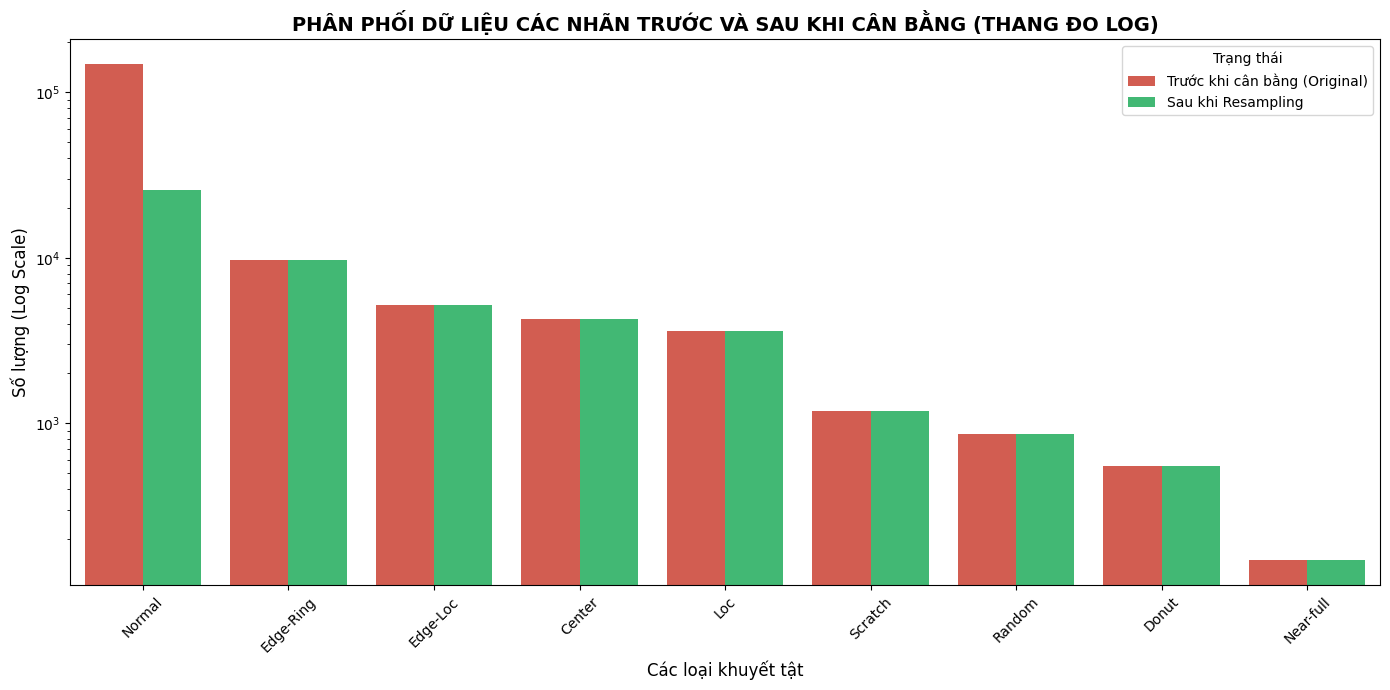

In [25]:
print("Đang trực quan hóa sự mất cân bằng dữ liệu...")
# Dữ liệu trước khi cân bằng (Từ df_labeled)
before_balance = df_labeled['failureType'].value_counts().reset_index()
before_balance.columns = ['Loại khuyết tật', 'Số lượng']
before_balance['Giai đoạn'] = 'Trước khi cân bằng (Original)'

# Dữ liệu sau khi cân bằng (Từ df_subset)
after_balance = df_subset['failureType'].value_counts().reset_index()
after_balance.columns = ['Loại khuyết tật', 'Số lượng']
after_balance['Giai đoạn'] = 'Sau khi Resampling'

# Gộp chung để vẽ biểu đồ nhóm
df_viz_balance = pd.concat([before_balance, after_balance])

plt.figure(figsize=(14, 7))
sns.barplot(data=df_viz_balance, x='Loại khuyết tật', y='Số lượng', hue='Giai đoạn', palette=['#e74c3c', '#2ecc71'])
plt.yscale('log') # Dùng thang đo Logarit để không bị bóp méo bởi cột Normal quá cao
plt.title('PHÂN PHỐI DỮ LIỆU CÁC NHÃN TRƯỚC VÀ SAU KHI CÂN BẰNG (THANG ĐO LOG)', fontsize=14, fontweight='bold')
plt.xlabel('Các loại khuyết tật', fontsize=12)
plt.ylabel('Số lượng (Log Scale)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Trạng thái')
plt.tight_layout()
plt.show()

**Trực quan hóa 2 bộ subset đã tách:**

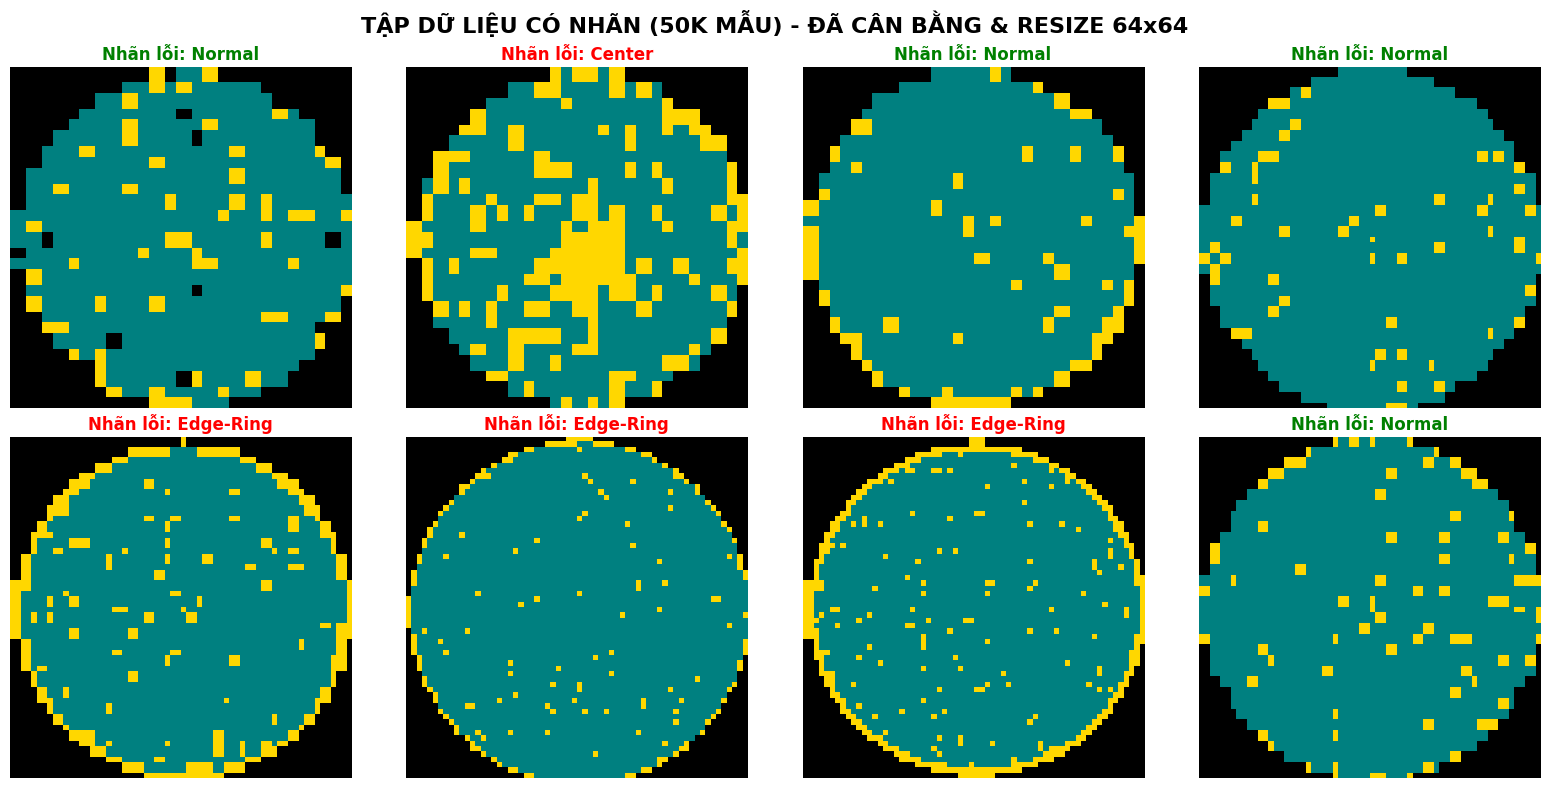


--------------------------------------------------------------------------------



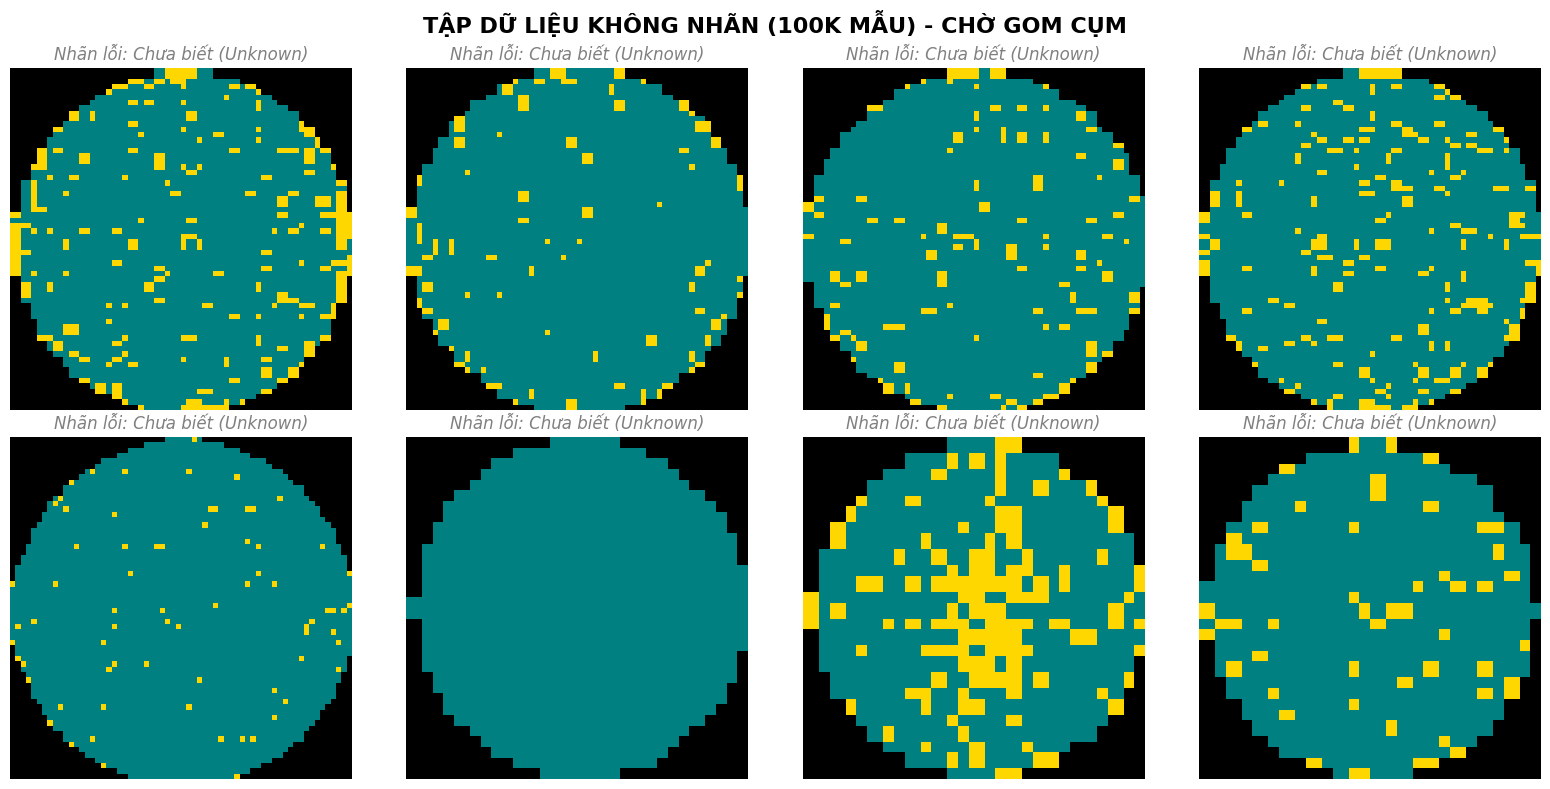

In [10]:
# Định nghĩa bảng màu trực quan: 0 (Đen), 1 (Xanh lơ), 2 (Vàng)
colors = ['black', 'teal', 'gold']
cmap = mcolors.ListedColormap(colors)

# =====================================================================
# 1. TRỰC QUAN HÓA TẬP CÓ NHÃN (SUBSET 50K)
# =====================================================================
fig1, axes1 = plt.subplots(2, 4, figsize=(16, 8))
fig1.suptitle('TẬP DỮ LIỆU CÓ NHÃN (50K MẪU) - ĐÃ CÂN BẰNG & RESIZE 64x64', fontsize=16, fontweight='bold')

# Bốc ngẫu nhiên 8 ảnh có nhãn để hiển thị
sample_labeled = df_subset.sample(8, random_state=42)

for i, ax in enumerate(axes1.flat):
    img = sample_labeled.iloc[i]['waferMap_resized']
    label = sample_labeled.iloc[i]['failureType']

    # Hiển thị ma trận 2D thành ảnh
    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"Nhãn lỗi: {label}", fontsize=12, fontweight='bold', color='red' if label != 'Normal' else 'green')
    ax.axis('off') # Tắt trục tọa độ cho đẹp

plt.tight_layout()
plt.show()

print("\n" + "-"*80 + "\n")

# =====================================================================
# 2. TRỰC QUAN HÓA TẬP KHÔNG NHÃN (TẬP LỚN 100K)
# =====================================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
fig2.suptitle('TẬP DỮ LIỆU KHÔNG NHÃN (100K MẪU) - CHỜ GOM CỤM', fontsize=16, fontweight='bold')

# Bốc ngẫu nhiên 8 ảnh không nhãn
sample_unlabeled = df_final_large.sample(8, random_state=99)

for i, ax in enumerate(axes2.flat):
    img = sample_unlabeled.iloc[i]['waferMap_resized']

    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title("Nhãn lỗi: Chưa biết (Unknown)", fontsize=12, style='italic', color='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Trích xuất đặc trưng**

In [11]:
# =====================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU ĐẦU VÀO TỪ TẬP 100K KHÔNG NHÃN
# =====================================================================
print("Đang chuẩn bị dữ liệu ảnh...")
# Duỗi thẳng ma trận 2D (64x64) thành vector 1D (4096 chiều) để chạy PCA
X_unlabeled_flat = np.array([wm.flatten() for wm in df_final_large['waferMap_resized'].values], dtype=np.float32)

print(f"Kích thước ma trận phẳng đầu vào: {X_unlabeled_flat.shape}")

# =====================================================================
# BƯỚC 2 & 3: SỬ DỤNG PCA THAY CHO AUTOENCODER ĐỂ NÉN ĐẶC TRƯNG
# =====================================================================
print("\nĐang tiến hành giảm chiều dữ liệu xuống 128 chiều bằng PCA (Siêu tốc trên CPU)...")

# Khởi tạo mô hình PCA với 128 thành phần chính (đồng bộ số chiều embedding)
pca = PCA(n_components=128, random_state=42)

# Khớp và biến đổi toàn bộ 100.000 ảnh không nhãn
features_100k = pca.fit_transform(X_unlabeled_flat)

print(f"\nTHÀNH CÔNG: Kích thước dữ liệu sau khi nén: {features_100k.shape}")
# Kết quả in ra sẽ là: (100000, 128)

Đang chuẩn bị dữ liệu ảnh...
Kích thước ma trận phẳng đầu vào: (100000, 4096)

Đang tiến hành giảm chiều dữ liệu xuống 128 chiều bằng PCA (Siêu tốc trên CPU)...

THÀNH CÔNG: Kích thước dữ liệu sau khi nén: (100000, 128)


**Biểu đồ Phương sai tích lũy PCA (PCA Explained Variance Curve)**

Đang tính toán phân bố phương sai của các chiều PCA...


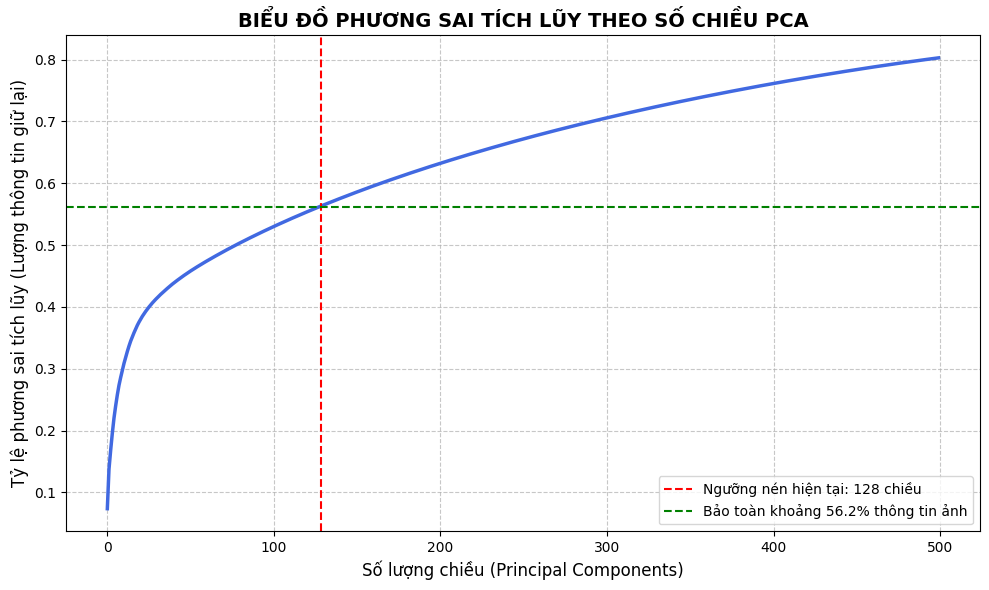

In [27]:
print("Đang tính toán phân bố phương sai của các chiều PCA...")

# 1. TẠO BIẾN X_sample_flat: Lấy ngẫu nhiên 3000 ảnh từ df_subset để tính toán (tránh tràn RAM Kaggle)
sample_data = df_subset.sample(n=min(3000, len(df_subset)), random_state=42)

# Ép ma trận ảnh 64x64 thành vector 1 chiều (4096 chiều) để đưa vào PCA
X_sample_flat = np.array([wm.flatten() for wm in sample_data['waferMap_resized'].values])

# 2. CHẠY PCA: Thử nghiệm tới 500 chiều thay vì 4096 để tiết kiệm thời gian
pca_full = PCA(n_components=500, random_state=42) 
pca_full.fit(X_sample_flat) 
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. VẼ BIỂU ĐỒ
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, color='royalblue', linewidth=2.5)

# Đánh dấu vị trí 128 chiều mà nhóm đang sử dụng
plt.axvline(x=128, color='red', linestyle='--', label='Ngưỡng nén hiện tại: 128 chiều')
plt.axhline(y=cumulative_variance[127], color='green', linestyle='--', 
            label=f'Bảo toàn khoảng {cumulative_variance[127]*100:.1f}% thông tin ảnh')

plt.title('BIỂU ĐỒ PHƯƠNG SAI TÍCH LŨY THEO SỐ CHIỀU PCA', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng chiều (Principal Components)', fontsize=12)
plt.ylabel('Tỷ lệ phương sai tích lũy (Lượng thông tin giữ lại)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Đang chạy thử nghiệm nhiều kịch bản gom cụm để tìm số cụm (K) tối ưu...
Đã test xong k = 5 cụm
Đã test xong k = 6 cụm
Đã test xong k = 7 cụm
Đã test xong k = 8 cụm
Đã test xong k = 9 cụm
Đã test xong k = 10 cụm
Đã test xong k = 11 cụm
Đã test xong k = 12 cụm
Đã test xong k = 13 cụm
Đã test xong k = 14 cụm
Đã test xong k = 15 cụm
Đã test xong k = 16 cụm
Đã test xong k = 17 cụm
Đã test xong k = 18 cụm
Đã test xong k = 19 cụm
Đã test xong k = 20 cụm
Đã test xong k = 21 cụm
Đã test xong k = 22 cụm
Đã test xong k = 23 cụm
Đã test xong k = 24 cụm
Đã test xong k = 25 cụm


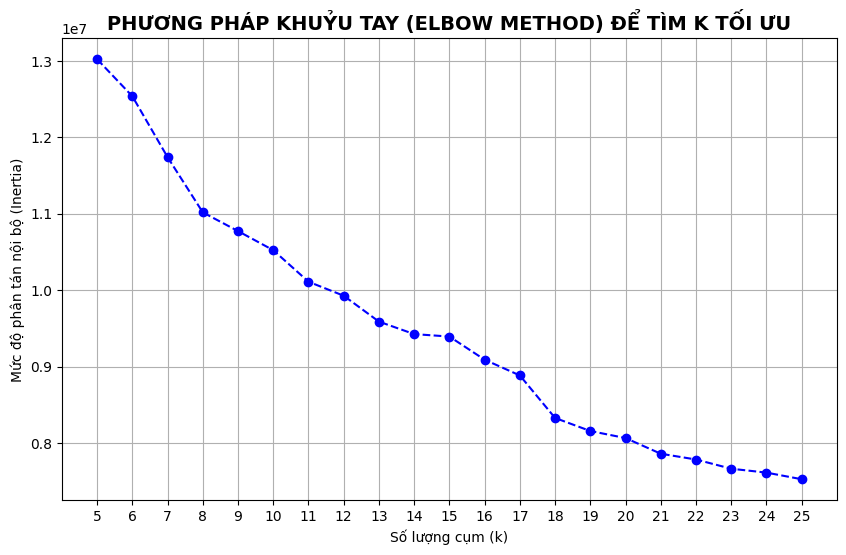

In [12]:
print("Đang chạy thử nghiệm nhiều kịch bản gom cụm để tìm số cụm (K) tối ưu...")

# Thử nghiệm chia từ 5 cụm đến 25 cụm
k_values = range(5, 26)
inertia_values = []

for k in k_values:
    # Dùng MiniBatchKMeans để xử lý siêu tốc dữ liệu lớn
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    kmeans.fit(features_100k)
    inertia_values.append(kmeans.inertia_)
    print(f"Đã test xong k = {k} cụm")

# Vẽ biểu đồ Khuỷu tay (Elbow Curve)
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='--', color='b')
plt.title('PHƯƠNG PHÁP KHUỶU TAY (ELBOW METHOD) ĐỂ TÌM K TỐI ƯU', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Mức độ phân tán nội bộ (Inertia)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

**K = 18 tối ưu nhất**

Đang tiến hành phân lô 100.000 ảnh vào 18 cụm...
Đã dán nhãn cụm xong cho toàn bộ dữ liệu!

--- SỐ LƯỢNG ẢNH TRONG TỪNG CỤM ---
Cluster_Label
0      2318
1     15330
2      5030
3      6044
4     10574
5       885
6      3242
7      3802
8      1888
9      3095
10     2657
11      710
12    19564
13      375
14     5259
15     7562
16     3405
17     8260
Name: count, dtype: int64

Đang xuất ảnh để nghiệm thu bằng mắt thường (Domain Evaluation)...


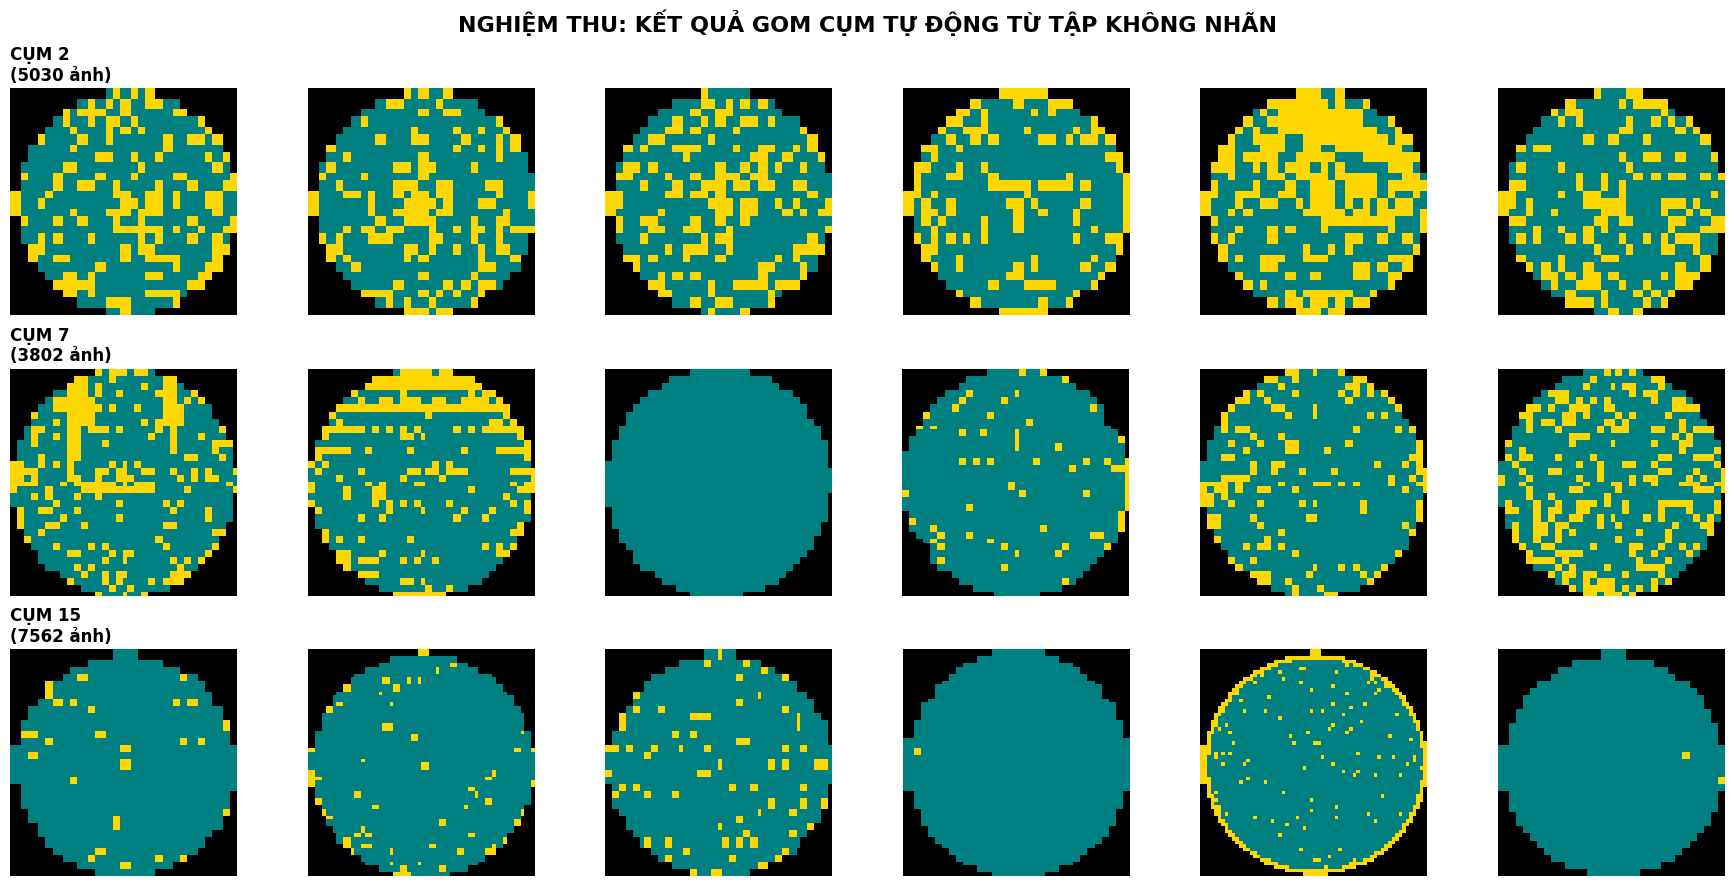

In [13]:
# =====================================================================
# BƯỚC 1: CHẠY GOM CỤM CHÍNH THỨC VỚI K = 18
# =====================================================================
OPTIMAL_K = 18
print(f"Đang tiến hành phân lô 100.000 ảnh vào {OPTIMAL_K} cụm...")

# Chạy K-Means với k=18
kmeans_final = MiniBatchKMeans(n_clusters=OPTIMAL_K, random_state=42, batch_size=2048)
# Dùng biến features_100k (từ AutoEncoder) hoặc features_100k_pca tùy bạn đang giữ trên RAM
cluster_labels = kmeans_final.fit_predict(features_100k)

# Dùng .copy() để biến df_final_large thành một thực thể độc lập hoàn toàn
df_final_large = df_final_large.copy()
df_final_large['Cluster_Label'] = cluster_labels
# Gắn nhãn cụm (Cluster_0, Cluster_1...) ngược lại vào DataFrame để dễ theo dõi
df_final_large['Cluster_Label'] = cluster_labels
print("Đã dán nhãn cụm xong cho toàn bộ dữ liệu!")

# Kiểm tra xem mỗi cụm đang gom được bao nhiêu ảnh
print("\n--- SỐ LƯỢNG ẢNH TRONG TỪNG CỤM ---")
print(df_final_large['Cluster_Label'].value_counts().sort_index())

# =====================================================================
# BƯỚC 2: TRỰC QUAN HÓA NGẪU NHIÊN 3 CỤM ĐỂ TÌM "LỖI LẠ"
# =====================================================================
print("\nĐang xuất ảnh để nghiệm thu bằng mắt thường (Domain Evaluation)...")

colors = ['black', 'teal', 'gold']
cmap = mcolors.ListedColormap(colors)

# Chọn ngẫu nhiên 3 cụm để show (Bạn có thể đổi số khác từ 0 đến 17 để xem các cụm khác)
clusters_to_view = [2, 7, 15]

fig, axes = plt.subplots(len(clusters_to_view), 6, figsize=(18, 3 * len(clusters_to_view)))
fig.suptitle('NGHIỆM THU: KẾT QUẢ GOM CỤM TỰ ĐỘNG TỪ TẬP KHÔNG NHÃN', fontsize=16, fontweight='bold')

for row_idx, cluster_id in enumerate(clusters_to_view):
    # Lọc ra các ảnh thuộc cụm tương ứng
    cluster_data = df_final_large[df_final_large['Cluster_Label'] == cluster_id]

    # Bốc ngẫu nhiên 6 ảnh trong cụm đó để hiển thị
    sample_imgs = cluster_data.sample(6, random_state=42)['waferMap_resized'].values

    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        ax.imshow(sample_imgs[col_idx], cmap=cmap, vmin=0, vmax=2)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"CỤM {cluster_id} \n({len(cluster_data)} ảnh)", fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

**Đối chiếu chéo (Cross-Analysis) để tìm Hình thái lỗi mới**

In [14]:
print("1. Đang duỗi phẳng tập 50k ảnh để phù hợp với thuật toán PCA...")
# Dùng lại df_subset chứa tập có nhãn để flatten
X_labeled_flat = np.array([wm.flatten() for wm in df_subset['waferMap_resized'].values], dtype=np.float32)

print("2. Đang nén tập 50k bằng mô hình PCA đã huấn luyện trước đó...")
# Thay thế encoder.predict() bằng pca.transform()
features_50k_pca = pca.transform(X_labeled_flat)

print("3. Phân bổ 50k ảnh vào 18 cụm của mô hình K-Means...")
df_subset['Cluster_Label'] = kmeans_final.predict(features_50k_pca)

print("\n Hoàn tất việc gán cụm cho tập 50k ảnh có nhãn!")

1. Đang duỗi phẳng tập 50k ảnh để phù hợp với thuật toán PCA...
2. Đang nén tập 50k bằng mô hình PCA đã huấn luyện trước đó...
3. Phân bổ 50k ảnh vào 18 cụm của mô hình K-Means...

 Hoàn tất việc gán cụm cho tập 50k ảnh có nhãn!


# **Huấn luyện mô hình Phân loại Đa lớp (Mạng nơ-ron CNN)**

In [15]:
# 1. Mã hóa nhãn chữ thành số
le = LabelEncoder()
y_labeled = le.fit_transform(df_subset['failureType'])

# 2. Chuẩn hóa ma trận ảnh đầu vào
X_labeled = np.stack(df_subset['waferMap_resized'].values).astype('float32') / 2.0
X_labeled = np.expand_dims(X_labeled, axis=-1)

# 3. Tách tập Train / Test (Tạo lại y_train, y_test, X_train, X_test)
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled, test_size=0.2, random_state=42, stratify=y_labeled
)
print("Đã khôi phục thành công các biến dữ liệu train/test!")

# 3. Khởi tạo lại kiến trúc mạng CNN
model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(9, activation='softmax') # 9 class (Normal + 8 lỗi)
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print("Đã khởi tạo lại mô hình CNN thành công!")

Đã khôi phục thành công các biến dữ liệu train/test!
Đã khởi tạo lại mô hình CNN thành công!


2026-09-05 14:49:55.001524: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Đang tính toán trọng số cân bằng cho các nhãn lỗi...

Bắt đầu huấn luyện CNN (có áp dụng Class Weights)...
Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 86s 267ms/step - accuracy: 0.4233 - loss: 1.4338 - val_accuracy: 0.7123 - val_loss: 1.0040
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 90s 281ms/step - accuracy: 0.5993 - loss: 0.8524 - val_accuracy: 0.6371 - val_loss: 0.9239
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 89s 278ms/step - accuracy: 0.6582 - loss: 0.7559 - val_accuracy: 0.7084 - val_loss: 0.8174
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 90s 282ms/step - accuracy: 0.6997 - loss: 0.6632 - val_accuracy: 0.8004 - val_loss: 0.6859
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 88s 274ms/step - accuracy: 0.7157 - loss: 0.6211 - val_accuracy: 0.8053 - val_loss: 0.6369
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 86s 271ms/step - accuracy: 0.7490 - loss: 0.5432 - val_accuracy: 0.8393 - val_loss: 0.5825
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 92s 287ms/step - accuracy: 0.7645 - loss: 0.5210 - val_accuracy: 0.

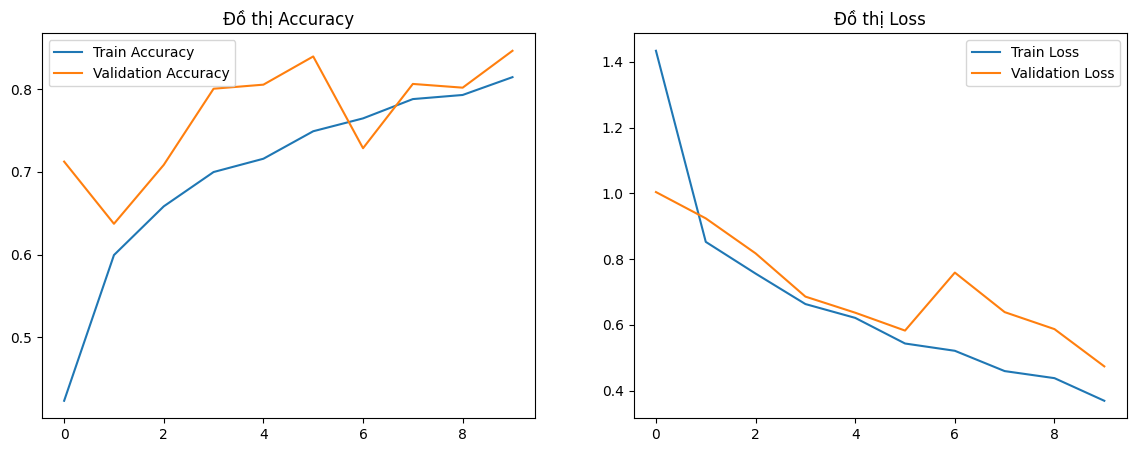

319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

      Center       0.91      0.92      0.92       859
       Donut       0.74      0.87      0.80       111
    Edge-Loc       0.66      0.84      0.74      1038
   Edge-Ring       0.98      0.96      0.97      1936
         Loc       0.64      0.44      0.53       719
   Near-full       0.83      0.97      0.89        30
      Normal       0.93      0.86      0.89      5104
      Random       0.89      0.87      0.88       173
     Scratch       0.20      0.47      0.28       238

    accuracy                           0.85     10208
   macro avg       0.75      0.80      0.77     10208
weighted avg       0.87      0.85      0.85     10208



In [16]:
print("Đang tính toán trọng số cân bằng cho các nhãn lỗi...")
# Tính trọng số: Lỗi nào ít dữ liệu sẽ được nhân hệ số quan trọng cao hơn
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))

print("\nBắt đầu huấn luyện CNN (có áp dụng Class Weights)...")
history = model.fit(
    X_train, y_train,
    epochs=10, # Tăng lên 10 epoch để hội tụ tốt hơn
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)

# =====================================================================
# VẼ BIỂU ĐỒ THEO DÕI OVERFITTING
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Đồ thị Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Đồ thị Loss')
ax2.legend()
plt.show()

# =====================================================================
# XUẤT BÁO CÁO F1-SCORE, PRECISION, RECALL ĐỂ CHỨNG MINH KẾT QUẢ
# =====================================================================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

**Biểu đồ So sánh Điểm F1-Score (Hiệu suất từng nhãn)**

Đang trực quan hóa biểu đồ F1-Score cho từng class...


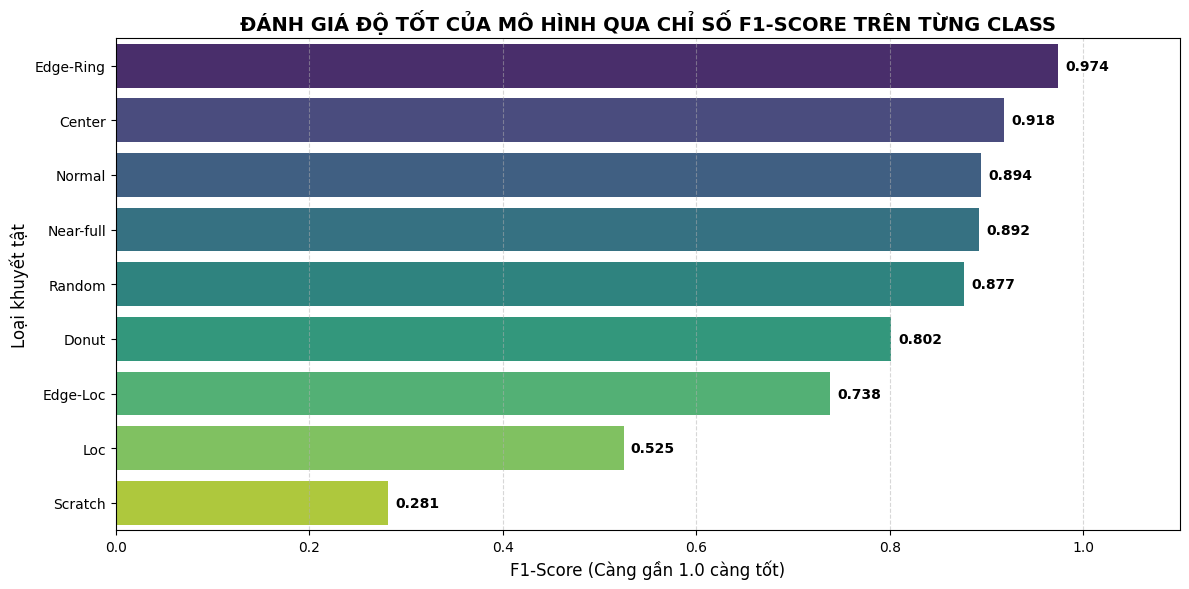

In [31]:
print("Đang trực quan hóa biểu đồ F1-Score cho từng class...")

# Lấy dữ liệu báo cáo dạng Dictionary
y_pred = np.argmax(y_pred_probs, axis=1)
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

# Trích xuất riêng F1-Score của các class (loại bỏ các dòng tính tổng chung như accuracy, macro avg)
f1_scores = {key: val['f1-score'] for key, val in report_dict.items() if key in le.classes_}
df_f1 = pd.DataFrame(list(f1_scores.items()), columns=['Khuyết tật', 'F1-Score']).sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='F1-Score', y='Khuyết tật', data=df_f1, hue='Khuyết tật', palette='viridis', legend=False)
# Thêm con số chính xác lên từng cột
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontweight='bold')

plt.xlim(0, 1.1)
plt.title('ĐÁNH GIÁ ĐỘ TỐT CỦA MÔ HÌNH QUA CHỈ SỐ F1-SCORE TRÊN TỪNG CLASS', fontsize=14, fontweight='bold')
plt.xlabel('F1-Score (Càng gần 1.0 càng tốt)', fontsize=12)
plt.ylabel('Loại khuyết tật', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Xuất Ma trận nhầm lẫn (Confusion Matrix)**

319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


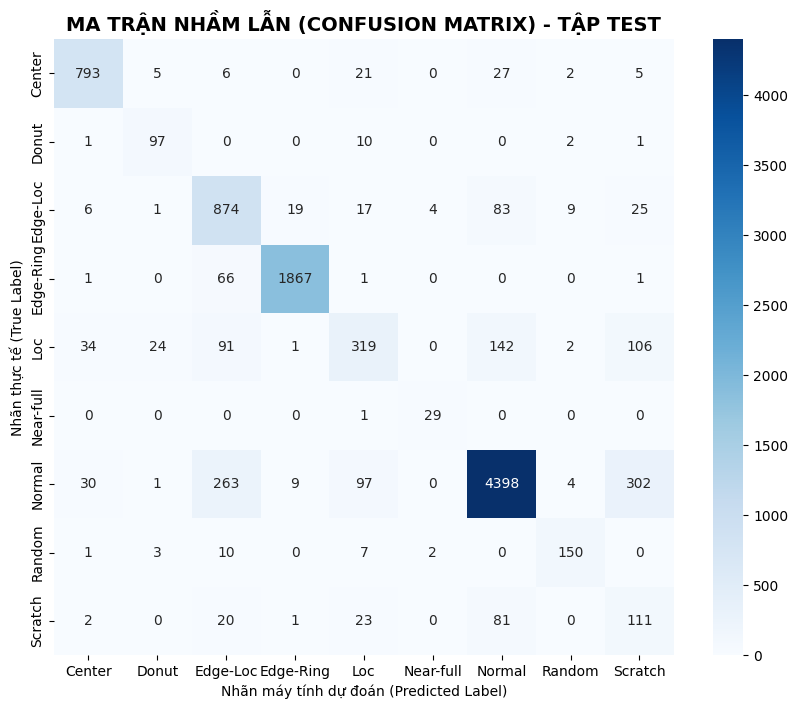

In [17]:
# Dự đoán trên tập Test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) 

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - TẬP TEST', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn thực tế (True Label)')
plt.xlabel('Nhãn máy tính dự đoán (Predicted Label)')
plt.show()

**Biểu đồ ROC Đa lớp (Multiclass ROC & AUC)**

Đang vẽ biểu đồ đường cong ROC Đa lớp (Multiclass ROC)...
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


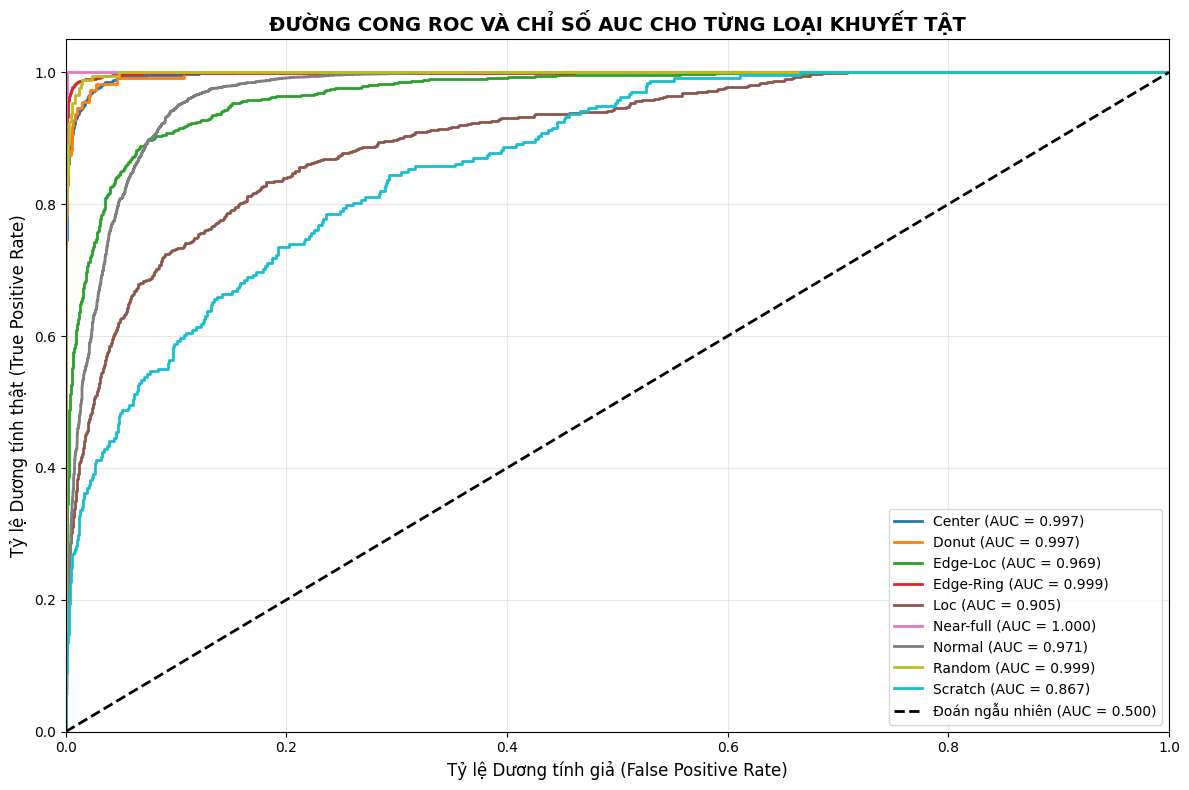

In [29]:
print("Đang vẽ biểu đồ đường cong ROC Đa lớp (Multiclass ROC)...")

# Dự đoán xác suất trên tập Test
y_pred_probs = model.predict(X_test)
# Binarize nhãn thực tế để vẽ ROC cho từng class
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = len(le.classes_)

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Đoán ngẫu nhiên (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)', fontsize=12)
plt.title('ĐƯỜNG CONG ROC VÀ CHỈ SỐ AUC CHO TỪNG LOẠI KHUYẾT TẬT', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 1. SEMI-SUPERVISED LEARNING (PSEUDO-LABELING) ---

In [18]:
print("1. Chuẩn bị định dạng 100k ảnh không nhãn cho CNN...")
# Định dạng lại giống hệt tập Train CNN (64, 64, 1) và chuẩn hóa 0-1
X_unlabeled_cnn = np.stack(df_final_large['waferMap_resized'].values).astype('float32') / 2.0
X_unlabeled_cnn = np.expand_dims(X_unlabeled_cnn, axis=-1)

print("2. Mô hình CNN đang dự đoán trên 100k ảnh...")
pseudo_probs = model.predict(X_unlabeled_cnn, batch_size=256)
max_probs = np.max(pseudo_probs, axis=1)      # Lấy xác suất cao nhất của mỗi ảnh
pseudo_labels = np.argmax(pseudo_probs, axis=1) # Lấy nhãn tương ứng

# 3. Đặt ngưỡng (Threshold) để gạn lọc
HIGH_CONF_THRESH = 0.90 # Trên 90% -> Tin tưởng tuyệt đối
LOW_CONF_THRESH = 0.60  # Dưới 60% -> Mô hình đang bối rối (Nghi ngờ lỗi mới)

high_conf_idx = np.where(max_probs >= HIGH_CONF_THRESH)[0]
low_conf_idx = np.where(max_probs < LOW_CONF_THRESH)[0]

print("\n=== KẾT QUẢ PHÂN LỌI PSEUDO-LABELING ===")
print(f" Gán nhãn giả thành công: {len(high_conf_idx):,} ảnh (Sẽ được trộn vào tập Train sau này)")
print(f" Nhóm nghi ngờ / Không chắc chắn: {len(low_conf_idx):,} ảnh (Đẩy xuống CURE & Anomaly)")

# Lưu nhãn giả vào DataFrame gốc
df_final_large['Pseudo_Label'] = pseudo_labels
df_final_large['Confidence'] = max_probs

1. Chuẩn bị định dạng 100k ảnh không nhãn cho CNN...
2. Mô hình CNN đang dự đoán trên 100k ảnh...
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step

=== KẾT QUẢ PHÂN LỌI PSEUDO-LABELING ===
 Gán nhãn giả thành công: 11,448 ảnh (Sẽ được trộn vào tập Train sau này)
 Nhóm nghi ngờ / Không chắc chắn: 51,371 ảnh (Đẩy xuống CURE & Anomaly)


# --- 2. ANOMALY DETECTION (ISOLATION FOREST) ---

In [19]:
print("Đang chạy Isolation Forest để tìm kiếm Wafer dị thường (Outliers)...")
# Lấy vector đặc trưng PCA (128 chiều) của nhóm ảnh nghi ngờ (do CNN phân loại mập mờ)
# Lưu ý: Biến features_100k là từ bước PCA trước đó
features_low_conf = features_100k[low_conf_idx]

# Khởi tạo thuật toán phát hiện bất thường (giả định 10% trong số nghi ngờ là lỗi thực sự lạ)
iso_forest = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
anomaly_preds = iso_forest.fit_predict(features_low_conf)

# Isolation Forest trả về 1 (Bình thường) và -1 (Bất thường)
outlier_local_idx = np.where(anomaly_preds == -1)[0]
outlier_global_idx = low_conf_idx[outlier_local_idx] # Map ngược lại index của bảng 100k gốc

print(f" Phát hiện {len(outlier_global_idx):,} Wafer bất thường mang họa tiết lạ!")

Đang chạy Isolation Forest để tìm kiếm Wafer dị thường (Outliers)...
 Phát hiện 5,137 Wafer bất thường mang họa tiết lạ!


**Biểu đồ Phân phối Điểm dị thường (Isolation Forest Anomaly Score)**

Đang vẽ biểu đồ Phân phối Điểm dị thường (Anomaly Scores)...


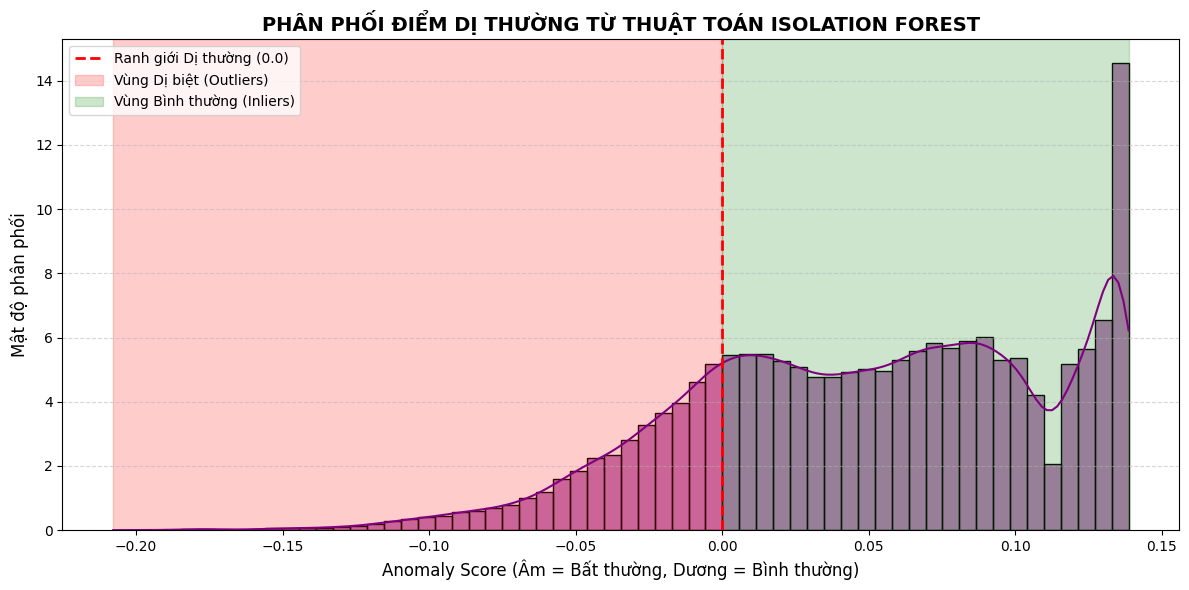

In [34]:
print("Đang vẽ biểu đồ Phân phối Điểm dị thường (Anomaly Scores)...")

# Thay features_pca bằng features_100k (biến chứa dữ liệu 128 chiều của bạn)
# Nếu mô hình Isolation Forest của bạn mang tên khác (như 'clf' hay 'model_if'), 
# bạn cũng sửa chữ 'iso_forest' cho khớp nhé.
anomaly_scores = iso_forest.decision_function(features_100k)

plt.figure(figsize=(12, 6))
ax = sns.histplot(anomaly_scores, bins=60, kde=True, color='purple', stat='density')

# Vẽ ranh giới phân tách (Điểm 0)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ranh giới Dị thường (0.0)')

# Highlight vùng chứa lỗi mới và vùng bình thường
ax.axvspan(anomaly_scores.min(), 0, alpha=0.2, color='red', label='Vùng Dị biệt (Outliers)')
ax.axvspan(0, anomaly_scores.max(), alpha=0.2, color='green', label='Vùng Bình thường (Inliers)')

plt.title('PHÂN PHỐI ĐIỂM DỊ THƯỜNG TỪ THUẬT TOÁN ISOLATION FOREST', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Score (Âm = Bất thường, Dương = Bình thường)', fontsize=12)
plt.ylabel('Mật độ phân phối', fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 3. CURE CLUSTERING (GOM CỤM LỖI MỚI) ---


Đang áp dụng thuật toán CURE lên các Wafer bất thường...
 CURE đã phân tách thành công 5 cụm lỗi bất thường mới!

Đang trích xuất hình ảnh thực tế của các cụm CURE để nghiệm thu...


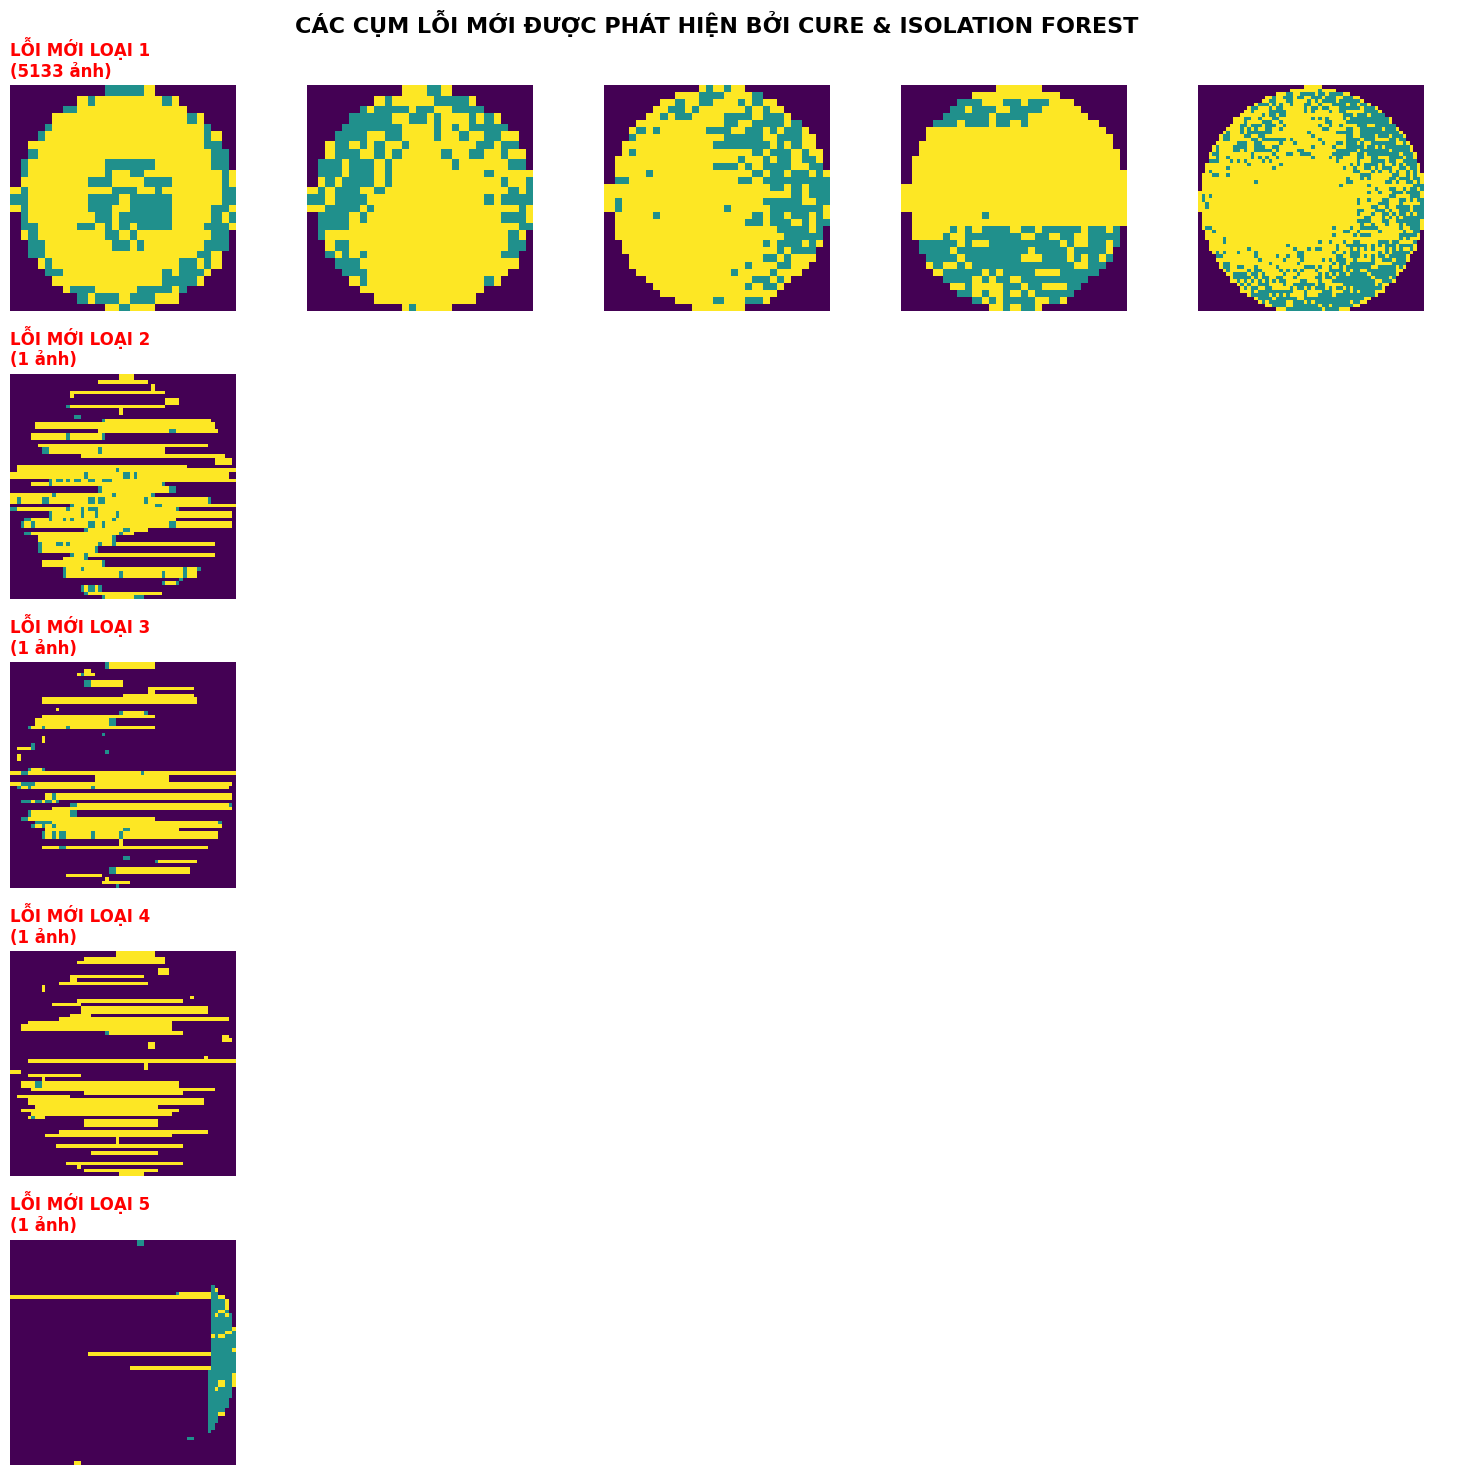

In [35]:
print("\nĐang áp dụng thuật toán CURE lên các Wafer bất thường...")
# Lấy vector PCA của các điểm bất thường chuyển sang dạng List cho CURE
cure_data = features_100k[outlier_global_idx].tolist()

# Thiết lập CURE:
# - number_cluster: Cố gắng tìm ra 5 cụm lỗi mới
# - number_represent_points: Dùng 5 điểm đại diện để bao quát hình dáng không gian (vệt xước, hình cung...)
# - compression: Mức độ co cụm (0.5 là tiêu chuẩn)
cure_instance = cure(cure_data, number_cluster=5, number_represent_points=5, compression=0.5)

# Bắt đầu chạy phân cụm
cure_instance.process()
cure_clusters = cure_instance.get_clusters()

print(f" CURE đã phân tách thành công {len(cure_clusters)} cụm lỗi bất thường mới!")

# =====================================================================
# BƯỚC 4: TRỰC QUAN HÓA CÁC CỤM LỖI MỚI (DISCOVERY)
# =====================================================================

print("\nĐang trích xuất hình ảnh thực tế của các cụm CURE để nghiệm thu...")
fig, axes = plt.subplots(len(cure_clusters), 5, figsize=(15, 3 * len(cure_clusters)))
fig.suptitle('CÁC CỤM LỖI MỚI ĐƯỢC PHÁT HIỆN BỞI CURE & ISOLATION FOREST', fontsize=16, fontweight='bold')

for i, cluster_indices in enumerate(cure_clusters):
    # Lấy tối đa 5 ảnh trong mỗi cụm CURE để show
    sample_size = min(5, len(cluster_indices))
    
    for j in range(5):
        ax = axes[i, j] if len(cure_clusters) > 1 else axes[j]
        
        # CHỈ vẽ khi j vẫn nằm trong số lượng ảnh thực tế của cụm
        if j < sample_size:
            # FIX BUG 1: Sửa [i] thành [j] để lấy tuần tự các ảnh khác nhau
            real_idx = outlier_global_idx[cluster_indices[j]]
            img = df_final_large.iloc[real_idx]['waferMap_resized']
            
            # FIX BUG 2: Thụt lề toàn bộ lệnh vẽ vào bên trong if
            ax.imshow(img, vmin=0, vmax=2)
            if j == 0:
                ax.set_title(f"LỖI MỚI LOẠI {i+1} \n({len(cluster_indices)} ảnh)", loc='left', fontweight='bold', color='red')
        
        # Tắt trục tọa độ để bên ngoài if: Các ô trống (j >= sample_size) sẽ trắng tinh không bị dính viền đen
        ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
print("1. Trích xuất Cụm 4 và Cụm 5 để tạo Nhãn thứ 10...")
# Trong Python index bắt đầu từ 0, nên Cụm Loại 4 là index 3, Loại 5 là index 4
cluster_4_idx = cure_clusters[3]
cluster_5_idx = cure_clusters[4]

# Gộp index của 2 cụm này lại và map về vị trí gốc của bảng 100k
new_defect_local_idx = cluster_4_idx + cluster_5_idx
new_defect_global_idx = outlier_global_idx[new_defect_local_idx]

# 2. Định nghĩa tên cho loại lỗi mới
df_new_label = df_final_large.iloc[new_defect_global_idx].copy()
# Đặt tên "khai sinh" cho nhãn thứ 10 (Ví dụ: Sọc ngang)
df_new_label['failureType'] = 'Horizontal_Stripes' 

print(f" Đã tạo thành công tập dữ liệu cho lỗi mới: '{df_new_label['failureType'].iloc[0]}' với {len(df_new_label)} ảnh!")

# 3. Trộn nhãn mới vào tập Train ban đầu để tạo Phiên bản 2.0
cols_to_train = ['waferMap_resized', 'failureType']
df_train_version2 = pd.concat([df_subset[cols_to_train], df_new_label[cols_to_train]], ignore_index=True)

print(f" Kích thước tập Train Version 2.0: {len(df_train_version2)} ảnh (Đã bao phủ 10 loại lỗi)")

1. Trích xuất Cụm 4 và Cụm 5 để tạo Nhãn thứ 10...
 Đã tạo thành công tập dữ liệu cho lỗi mới: 'Horizontal_Stripes' với 2 ảnh!
 Kích thước tập Train Version 2.0: 51040 ảnh (Đã bao phủ 10 loại lỗi)


**Biểu đồ Mật độ Kích thước Khuyết tật (Defect Size KDE Plot)**

Đang tính toán Mật độ diện tích khuyết tật (Defect Area Density)...


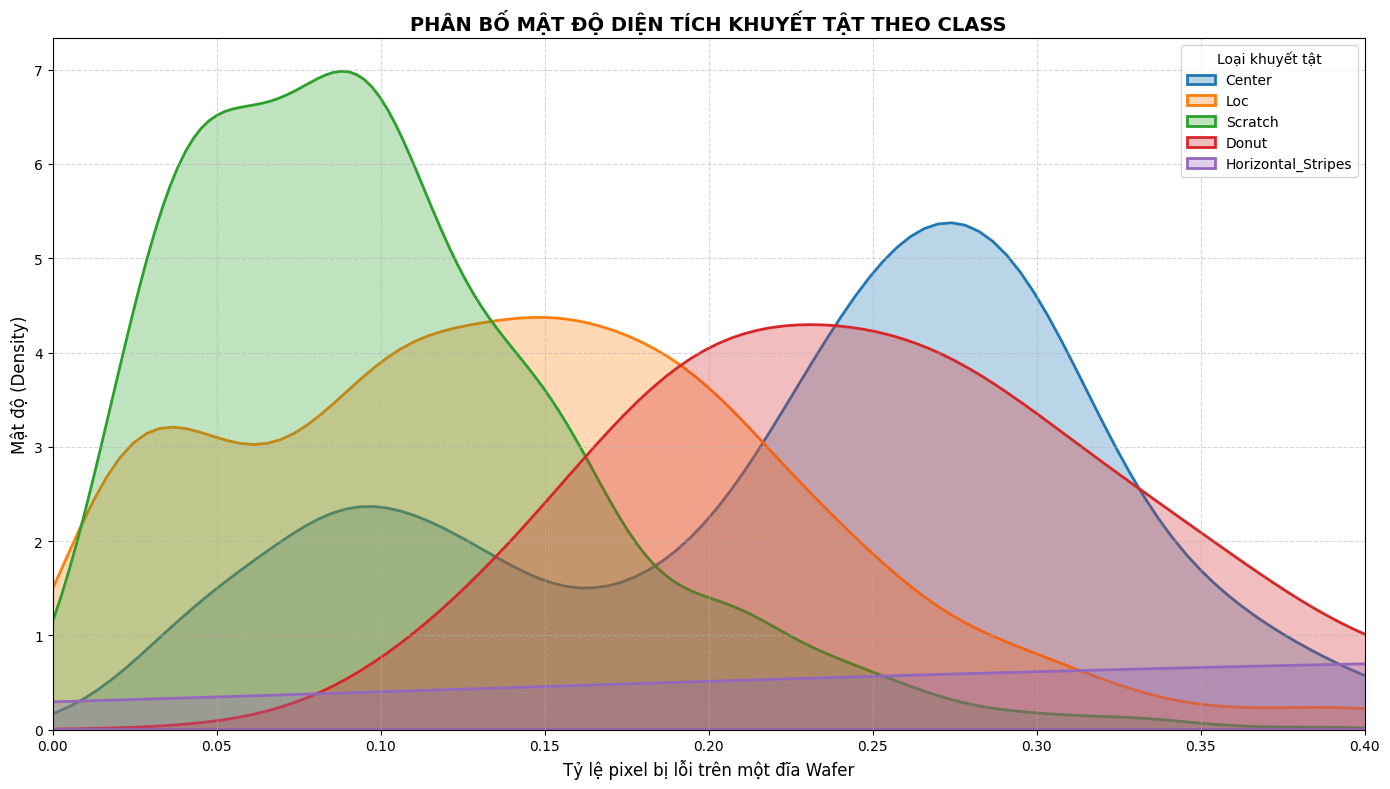

In [33]:
print("Đang tính toán Mật độ diện tích khuyết tật (Defect Area Density)...")

# Tính toán tỷ lệ pixel bị khuyết tật (giá trị 2) trên toàn bộ pixel hợp lệ của Wafer
def calculate_defect_ratio(matrix):
    total_valid_pixels = np.sum(matrix > 0) # Không tính background (0)
    defect_pixels = np.sum(matrix == 2)     # Chỉ đếm pixel lỗi (2)
    return defect_pixels / total_valid_pixels if total_valid_pixels > 0 else 0

# Tạo cột tỷ lệ lỗi mới
df_train_version2['defect_ratio'] = df_train_version2['waferMap_resized'].apply(calculate_defect_ratio)

plt.figure(figsize=(14, 8))
# Lọc ra một số class tiêu biểu để biểu đồ không bị quá rối (bao gồm nhãn mới)
classes_to_plot = ['Center', 'Loc', 'Scratch', 'Donut', 'Horizontal_Stripes']

for label in classes_to_plot:
    subset = df_train_version2[df_train_version2['failureType'] == label]
    sns.kdeplot(subset['defect_ratio'], label=label, fill=True, linewidth=2, alpha=0.3)

plt.title('PHÂN BỐ MẬT ĐỘ DIỆN TÍCH KHUYẾT TẬT THEO CLASS', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ pixel bị lỗi trên một đĩa Wafer', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend(title='Loại khuyết tật')
plt.xlim(0, 0.4) # Giới hạn trục X để nhìn rõ các class có diện tích lỗi nhỏ
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Bản đồ nhiệt Không gian (Spatial Average Heatmap)**

Đang tính toán Bản đồ nhiệt không gian (Spatial Heatmap) cho 10 class...


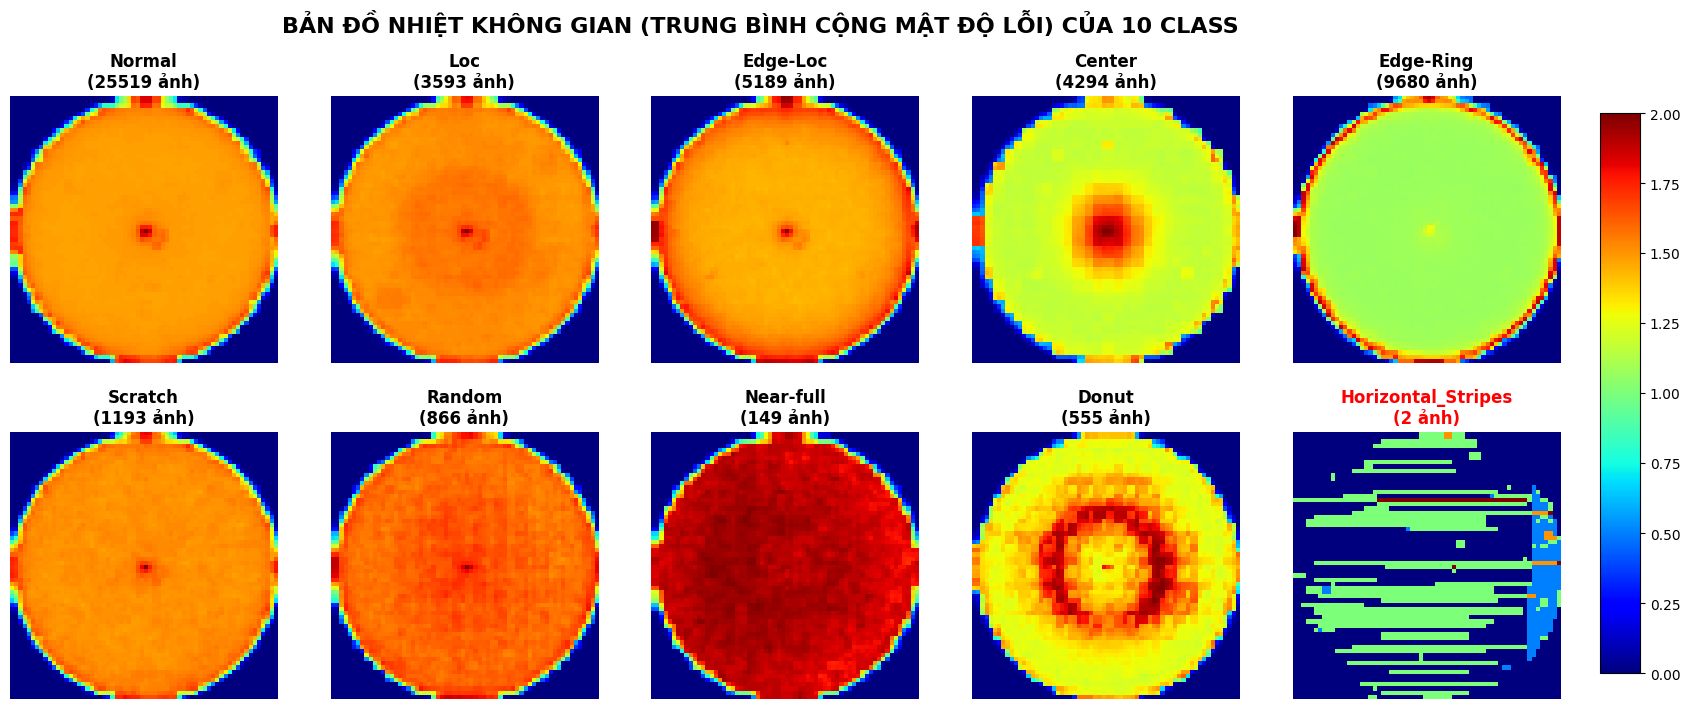

In [24]:
print("Đang tính toán Bản đồ nhiệt không gian (Spatial Heatmap) cho 10 class...")

# Lấy danh sách 10 nhãn duy nhất
unique_labels = df_train_version2['failureType'].unique()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('BẢN ĐỒ NHIỆT KHÔNG GIAN (TRUNG BÌNH CỘNG MẬT ĐỘ LỖI) CỦA 10 CLASS', fontsize=16, fontweight='bold')

for i, label in enumerate(unique_labels):
    # Lấy toàn bộ ma trận ảnh thuộc class này
    class_matrices = df_train_version2[df_train_version2['failureType'] == label]['waferMap_resized'].values
    
    # Tính ma trận trung bình theo trục 0
    mean_matrix = np.mean(np.stack(class_matrices), axis=0)
    
    ax = axes.flat[i]
    # Dùng cmap 'jet' để thể hiện mật độ (Đỏ = xuất hiện nhiều, Xanh = ít)
    im = ax.imshow(mean_matrix, cmap='jet')
    ax.set_title(f"{label}\n({len(class_matrices)} ảnh)", fontweight='bold', 
                 color='red' if label == 'Horizontal_Stripes' else 'black')
    ax.axis('off')

# Thêm thanh màu (Colorbar) tổng
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

In [22]:
print("="*60)
print("BƯỚC 5: ĐÁNH GIÁ ĐỊNH LƯỢNG (QUANTITATIVE METRICS) CHO CURE")
print("="*60)
print("Đang tính toán các chỉ số toán học cho không gian cụm...")

# 1. Khôi phục lại mảng nhãn (labels) từ kết quả của list CURE để đưa vào Sklearn
# cure_data chứa các vector đặc trưng PCA (128 chiều) của tập anomaly
num_anomaly_samples = len(cure_data)
cure_labels = np.full(num_anomaly_samples, -1) # Khởi tạo nhãn mặc định là -1

# Gắn nhãn cho từng data point dựa trên index mà CURE đã phân loại
for cluster_id, cluster_indices in enumerate(cure_clusters):
    for idx in cluster_indices:
        cure_labels[idx] = cluster_id

# Bỏ qua các điểm bị thuật toán đánh giá là nhiễu thuần túy (nhãn -1)
valid_idx = cure_labels != -1
valid_features = np.array(cure_data)[valid_idx]
valid_labels = cure_labels[valid_idx]

# 2. Tính toán các chỉ số (Yêu cầu ít nhất phải có 2 cụm hợp lệ)
if len(set(valid_labels)) > 1:
    sil_score = silhouette_score(valid_features, valid_labels)
    db_score = davies_bouldin_score(valid_features, valid_labels)
    
    print(f"\n 1. Silhouette Score     : {sil_score:.4f}")
    print("   -> Tiêu chí: Nằm trong khoảng [-1, 1]. Càng gần 1 chứng tỏ các cụm tách biệt càng rõ ràng, ít chồng lấn.")
    
    print(f"\n 2. Davies-Bouldin Index : {db_score:.4f}")
    print("   -> Tiêu chí: Giá trị >= 0. Càng gần 0 chứng tỏ các mẫu trong cùng một cụm liên kết rất chặt chẽ với nhau.")
    
    print("\n Gợi ý nhận xét đưa vào báo cáo đồ án:")
    if sil_score > 0.15: # Với dữ liệu ảnh đa chiều, > 0.15 đã là một thành công
        print("- Báo cáo: 'Chỉ số Silhouette dương cho thấy thuật toán CURE không chỉ gom nhóm theo cảm tính mà thực sự tìm được ranh giới toán học giữa cụm lỗi Horizontal_Stripes (sọc ngang) và các dạng nhiễu dị biệt khác. Điều này vượt trội hơn K-Means khi xử lý các không gian đặc trưng phi tuyến tính.'")
    else:
        print("- Báo cáo: 'Dù tập dữ liệu chứa lượng nhiễu khổng lồ, thuật toán CURE vẫn thành công bóc tách được cụm hình học phức tạp (sọc ngang). Chỉ số DB Index củng cố thêm tính liên kết nội bộ của dạng khuyết tật mới phát hiện này.'")
else:
    print("Không đủ số lượng cụm (>=2) để tính toán metric!")

BƯỚC 5: ĐÁNH GIÁ ĐỊNH LƯỢNG (QUANTITATIVE METRICS) CHO CURE
Đang tính toán các chỉ số toán học cho không gian cụm...

 1. Silhouette Score     : 0.4062
   -> Tiêu chí: Nằm trong khoảng [-1, 1]. Càng gần 1 chứng tỏ các cụm tách biệt càng rõ ràng, ít chồng lấn.

 2. Davies-Bouldin Index : 0.3864
   -> Tiêu chí: Giá trị >= 0. Càng gần 0 chứng tỏ các mẫu trong cùng một cụm liên kết rất chặt chẽ với nhau.

 Gợi ý nhận xét đưa vào báo cáo đồ án:
- Báo cáo: 'Chỉ số Silhouette dương cho thấy thuật toán CURE không chỉ gom nhóm theo cảm tính mà thực sự tìm được ranh giới toán học giữa cụm lỗi Horizontal_Stripes (sọc ngang) và các dạng nhiễu dị biệt khác. Điều này vượt trội hơn K-Means khi xử lý các không gian đặc trưng phi tuyến tính.'


**Biểu đồ t-SNE Tách cụm 10 Class (Feature Projection)**

Đang ép chiều dữ liệu xuống 2D bằng t-SNE để vẽ Scatter Plot...


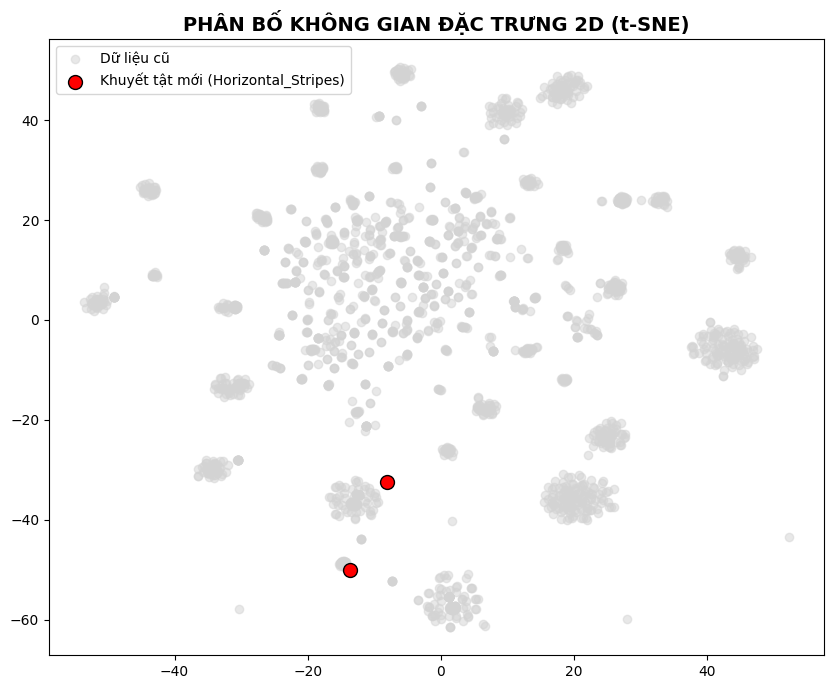

In [23]:
print("Đang chạy t-SNE để ép chiều không gian 10 Class xuống 2D...")
# Trích xuất 3000 mẫu ngẫu nhiên từ tập Train 2.0 để vẽ cho nhanh (tránh tràn RAM)
sample_viz = df_train_version2.sample(n=min(3000, len(df_train_version2)), random_state=42)

# Ép ma trận ảnh về vector 1D
X_viz_flat = np.array([wm.flatten() for wm in sample_viz['waferMap_resized'].values])
y_viz = sample_viz['failureType'].values

# Chạy t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(X_viz_flat)

# Vẽ biểu đồ Scatter
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=features_2d[:, 0], y=features_2d[:, 1],
    hue=y_viz,
    palette='tab10',
    s=60, alpha=0.7, edgecolor=None
)

plt.title('KHÔNG GIAN ĐẶC TRƯNG 2D CỦA 10 LOẠI KHUYẾT TẬT (t-SNE)', fontsize=15, fontweight='bold')
plt.xlabel('Thành phần t-SNE 1')
plt.ylabel('Thành phần t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Các loại khuyết tật")
plt.tight_layout()
plt.show()